# Etape 1 : Importation des bibliothèques

In [18]:
import joblib
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
import pandas as pd


# Etape 2 : Chargement  des modèles

In [19]:

# Charger les modèles
model_log = joblib.load("modele_logistique.pkl")
model_tree = joblib.load("modele_arbre.pkl")
X_test = joblib.load("X_test.pkl")
y_test = joblib.load("y_test.pkl")


# Etape 3   : Prédiction 

In [20]:
seuil = 0.45

# Régression logistique
y_proba_log = model_log.predict_proba(X_test)[:, 1]
y_pred_log = (y_proba_log >= seuil).astype(int)

# Arbre de décision
y_proba_tree = model_tree.predict_proba(X_test)[:, 1]
y_pred_tree = (y_proba_tree >= seuil).astype(int)

# Etape 3   : Comparaison des modèles

In [21]:
def evaluer_modele(nom, y_true, y_pred, y_proba):
    return {
        "Modèle": nom,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision_classe_1": precision_score(y_true, y_pred),
        "Recall_classe_1": recall_score(y_true, y_pred),
        "F1_classe_1": f1_score(y_true, y_pred),
        "ROC_AUC": roc_auc_score(y_true, y_proba)
    }

In [22]:
resultats = pd.DataFrame([
    evaluer_modele("Régression logistique", y_test, y_pred_log, y_proba_log),
    evaluer_modele("Arbre de décision", y_test, y_pred_tree, y_proba_tree)
])

resultats = resultats.sort_values(by="ROC_AUC", ascending=False)

print(resultats)

                  Modèle  Accuracy  Precision_classe_1  Recall_classe_1  \
0  Régression logistique  0.671202            0.298913         0.774648   
1      Arbre de décision  0.690476            0.309038         0.746479   

   F1_classe_1   ROC_AUC  
0     0.431373  0.780415  
1     0.437113  0.778397  


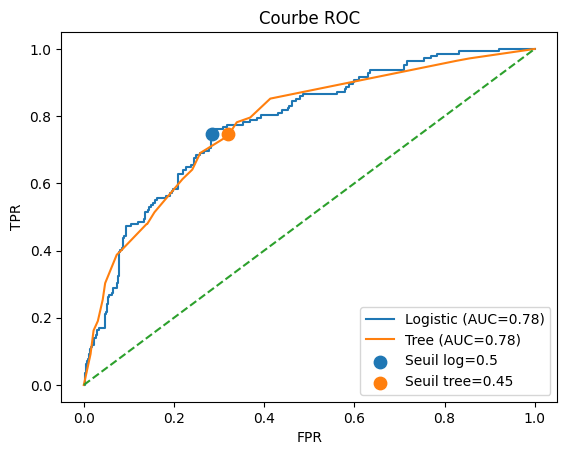

In [27]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt
import numpy as np

# ROC
fpr_log, tpr_log, thresholds_log = roc_curve(y_test, y_proba_log)
fpr_tree, tpr_tree, thresholds_tree = roc_curve(y_test, y_proba_tree)

# AUC
auc_log = roc_auc_score(y_test, y_proba_log)
auc_tree = roc_auc_score(y_test, y_proba_tree)

# seuils choisis
seuil_log = 0.5
seuil_tree = 0.45

# trouver le point le plus proche du seuil
idx_log = np.argmin(np.abs(thresholds_log - seuil_log))
idx_tree = np.argmin(np.abs(thresholds_tree - seuil_tree))

# Plot
plt.figure()

plt.plot(fpr_log, tpr_log, label=f"Logistic (AUC={auc_log:.2f})")
plt.plot(fpr_tree, tpr_tree, label=f"Tree (AUC={auc_tree:.2f})")

# ajouter les points des seuils
plt.scatter(fpr_log[idx_log], tpr_log[idx_log], label=f"Seuil log={seuil_log}", s=80)
plt.scatter(fpr_tree[idx_tree], tpr_tree[idx_tree], label=f"Seuil tree={seuil_tree}", s=80)

plt.plot([0,1], [0,1], '--')

plt.xlabel("FPR")
plt.ylabel("TPR")
plt.title("Courbe ROC")
plt.legend()
plt.show()

### Analyse des résultats

Les deux modèles présentent des performances globalement proches.

- L’**arbre de décision** obtient une **accuracy légèrement supérieure** ainsi qu’un **F1-score légèrement meilleur**, ce qui indique un meilleur compromis global entre précision et rappel.
- La **régression logistique** présente un **recall plus élevé sur la classe 1**, ce qui signifie qu’elle détecte mieux les employés à risque de départ.
- Les scores de **ROC-AUC sont très similaires**, ce qui montre que les deux modèles ont une capacité comparable à discriminer les classes.

---

### Choix du modèle

Le choix du modèle dépend de l’objectif métier :

- Si l’objectif est de **détecter un maximum d’employés à risque de départ**, la **régression logistique** est préférable grâce à son recall plus élevé.
- Si l’on cherche un **meilleur équilibre global entre détection et précision**, l’**arbre de décision** est légèrement plus performant.

---

### Conclusion

Les deux modèles étant proches en performance, le choix final dépend du compromis souhaité :

- **Régression logistique** : meilleure détection des départs (recall élevé)  
- **Arbre de décision** : meilleur équilibre global (F1-score et accuracy légèrement supérieurs)

Dans un contexte RH où il est souvent préférable de ne pas manquer un employé à risque, la régression logistique peut être privilégiée.